In [ ]:
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split

# pd.set_option('display.float_format', lambda x: ':.2f'.format(x))
# Option 1: f-string (recommended)
pd.set_option('display.float_format', lambda x: f'{x:.2f}')
np.set_printoptions(suppress=True)

In [ ]:
df_customers = pd.read_csv('customers.csv')
df_loan = pd.read_csv('loans.csv')
df_bureau = pd.read_csv('bureau_data.csv')

In [ ]:
df_customers.shape, df_loan.shape, df_bureau.shape

((50000, 12), (50000, 15), (50000, 8))

In [ ]:
df = pd.merge(df_customers, df_loan, on='cust_id')
df.head()

,cust_id,age,gender,marital_status,employment_status,income,number_of_dependants,residence_type,years_at_current_address,city,...,loan_amount,processing_fee,gst,net_disbursement,loan_tenure_months,principal_outstanding,bank_balance_at_application,disbursal_date,installment_start_dt,default
0,C00001,44,M,Married,Self-Employed,2586000,3,Owned,27,Delhi,...,2467000,49340.00,444060,1973600,33,1630408,873386,2019-07-24,2019-08-10,False
1,C00002,38,M,Married,Salaried,1206000,3,Owned,4,Chennai,...,3883000,77660.00,698940,3106400,30,709309,464100,2019-07-24,2019-08-15,False
2,C00003,46,F,Married,Self-Employed,2878000,3,Owned,24,Kolkata,...,2170000,43400.00,390600,1736000,21,1562399,1476042,2019-07-24,2019-08-21,False
3,C00004,55,F,Single,Self-Employed,3547000,1,Owned,15,Bangalore,...,1747000,34940.00,314460,1397600,6,1257839,1031094,2019-07-24,2019-08-09,False
4,C00005,37,M,Married,Salaried,3432000,3,Owned,28,Pune,...,4520000,90400.00,813600,3616000,28,1772334,1032458,2019-07-24,2019-08-02,False


In [ ]:
df = pd.merge(df, df_bureau)
df.head()

,cust_id,age,gender,marital_status,employment_status,income,number_of_dependants,residence_type,years_at_current_address,city,...,disbursal_date,installment_start_dt,default,number_of_open_accounts,number_of_closed_accounts,total_loan_months,delinquent_months,total_dpd,enquiry_count,credit_utilization_ratio
0,C00001,44,M,Married,Self-Employed,2586000,3,Owned,27,Delhi,...,2019-07-24,2019-08-10,False,1,1,42,0,0,3,7
1,C00002,38,M,Married,Salaried,1206000,3,Owned,4,Chennai,...,2019-07-24,2019-08-15,False,3,1,96,12,60,5,4
2,C00003,46,F,Married,Self-Employed,2878000,3,Owned,24,Kolkata,...,2019-07-24,2019-08-21,False,2,1,82,24,147,6,58
3,C00004,55,F,Single,Self-Employed,3547000,1,Owned,15,Bangalore,...,2019-07-24,2019-08-09,False,3,0,115,15,87,5,26
4,C00005,37,M,Married,Salaried,3432000,3,Owned,28,Pune,...,2019-07-24,2019-08-02,False,4,2,120,0,0,5,10


In [ ]:
df.info(max_cols=None)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 33 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   cust_id                      50000 non-null  object 
 1   age                          50000 non-null  int64  
 2   gender                       50000 non-null  object 
 3   marital_status               50000 non-null  object 
 4   employment_status            50000 non-null  object 
 5   income                       50000 non-null  int64  
 6   number_of_dependants         50000 non-null  int64  
 7   residence_type               49938 non-null  object 
 8   years_at_current_address     50000 non-null  int64  
 9   city                         50000 non-null  object 
 10  state                        50000 non-null  object 
 11  zipcode                      50000 non-null  int64  
 12  loan_id                      50000 non-null  object 
 13  loan_purpose    

In [ ]:
df['default'] = df['default'].astype(int)
df['default'].value_counts()

default
0    45703
1     4297
Name: count, dtype: int64

In [ ]:
X = df.drop(columns=['default'], axis="columns")
y = df['default']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)

In [ ]:
df_train = pd.concat([X_train, y_train], axis="columns")
df_test = pd.concat([X_test, y_test], axis="columns")

df_train.shape, df_test.shape

((37500, 33), (12500, 33))

### 1. Check NA value

In [ ]:
df_train.isna().sum()

cust_id                         0
age                             0
gender                          0
marital_status                  0
employment_status               0
income                          0
number_of_dependants            0
residence_type                 48
years_at_current_address        0
city                            0
state                           0
zipcode                         0
loan_id                         0
loan_purpose                    0
loan_type                       0
sanction_amount                 0
loan_amount                     0
processing_fee                  0
gst                             0
net_disbursement                0
loan_tenure_months              0
principal_outstanding           0
bank_balance_at_application     0
disbursal_date                  0
installment_start_dt            0
number_of_open_accounts         0
number_of_closed_accounts       0
total_loan_months               0
delinquent_months               0
total_dpd     

In [ ]:
df_train.residence_type.unique()

array(['Owned', 'Mortgage', 'Rented', nan], dtype=object)

### Use mode to replace categorical NA value

In [ ]:
mode_residence_type = df_train.residence_type.mode()[0]
mode_residence_type

'Owned'

In [ ]:
df_train.fillna({'residence_type': mode_residence_type}, inplace=True)

In [ ]:
df_train.isna().sum()

cust_id                        0
age                            0
gender                         0
marital_status                 0
employment_status              0
income                         0
number_of_dependants           0
residence_type                 0
years_at_current_address       0
city                           0
state                          0
zipcode                        0
loan_id                        0
loan_purpose                   0
loan_type                      0
sanction_amount                0
loan_amount                    0
processing_fee                 0
gst                            0
net_disbursement               0
loan_tenure_months             0
principal_outstanding          0
bank_balance_at_application    0
disbursal_date                 0
installment_start_dt           0
number_of_open_accounts        0
number_of_closed_accounts      0
total_loan_months              0
delinquent_months              0
total_dpd                      0
enquiry_co

In [ ]:
df_train.residence_type.unique()

array(['Owned', 'Mortgage', 'Rented'], dtype=object)

### Check duplicated

In [ ]:
df_train.duplicated().sum()

np.int64(0)

In [ ]:
df_train.columns

Index(['cust_id', 'age', 'gender', 'marital_status', 'employment_status',
       'income', 'number_of_dependants', 'residence_type',
       'years_at_current_address', 'city', 'state', 'zipcode', 'loan_id',
       'loan_purpose', 'loan_type', 'sanction_amount', 'loan_amount',
       'processing_fee', 'gst', 'net_disbursement', 'loan_tenure_months',
       'principal_outstanding', 'bank_balance_at_application',
       'disbursal_date', 'installment_start_dt', 'number_of_open_accounts',
       'number_of_closed_accounts', 'total_loan_months', 'delinquent_months',
       'total_dpd', 'enquiry_count', 'credit_utilization_ratio', 'default'],
      dtype='object')

In [ ]:
columns_continuous = ['age', 'income', 'number_of_dependants', 'years_at_current_address', 
                      'sanction_amount', 'loan_amount', 'processing_fee', 'gst', 'net_disbursement', 
                      'loan_tenure_months','principal_outstanding', 'bank_balance_at_application',
                      'number_of_open_accounts','number_of_closed_accounts', 'total_loan_months', 'delinquent_months',
                       'total_dpd', 'enquiry_count', 'credit_utilization_ratio']

columns_categorical = ['gender', 'marital_status', 'employment_status', 'residence_type', 'city', 
                       'state', 'zipcode', 'loan_purpose', 'loan_type', 'default']

columns_continuous, columns_categorical

(['age',
  'income',
  'number_of_dependants',
  'years_at_current_address',
  'sanction_amount',
  'loan_amount',
  'processing_fee',
  'gst',
  'net_disbursement',
  'loan_tenure_months',
  'principal_outstanding',
  'bank_balance_at_application',
  'number_of_open_accounts',
  'number_of_closed_accounts',
  'total_loan_months',
  'delinquent_months',
  'total_dpd',
  'enquiry_count',
  'credit_utilization_ratio'],
 ['gender',
  'marital_status',
  'employment_status',
  'residence_type',
  'city',
  'state',
  'zipcode',
  'loan_purpose',
  'loan_type',
  'default'])

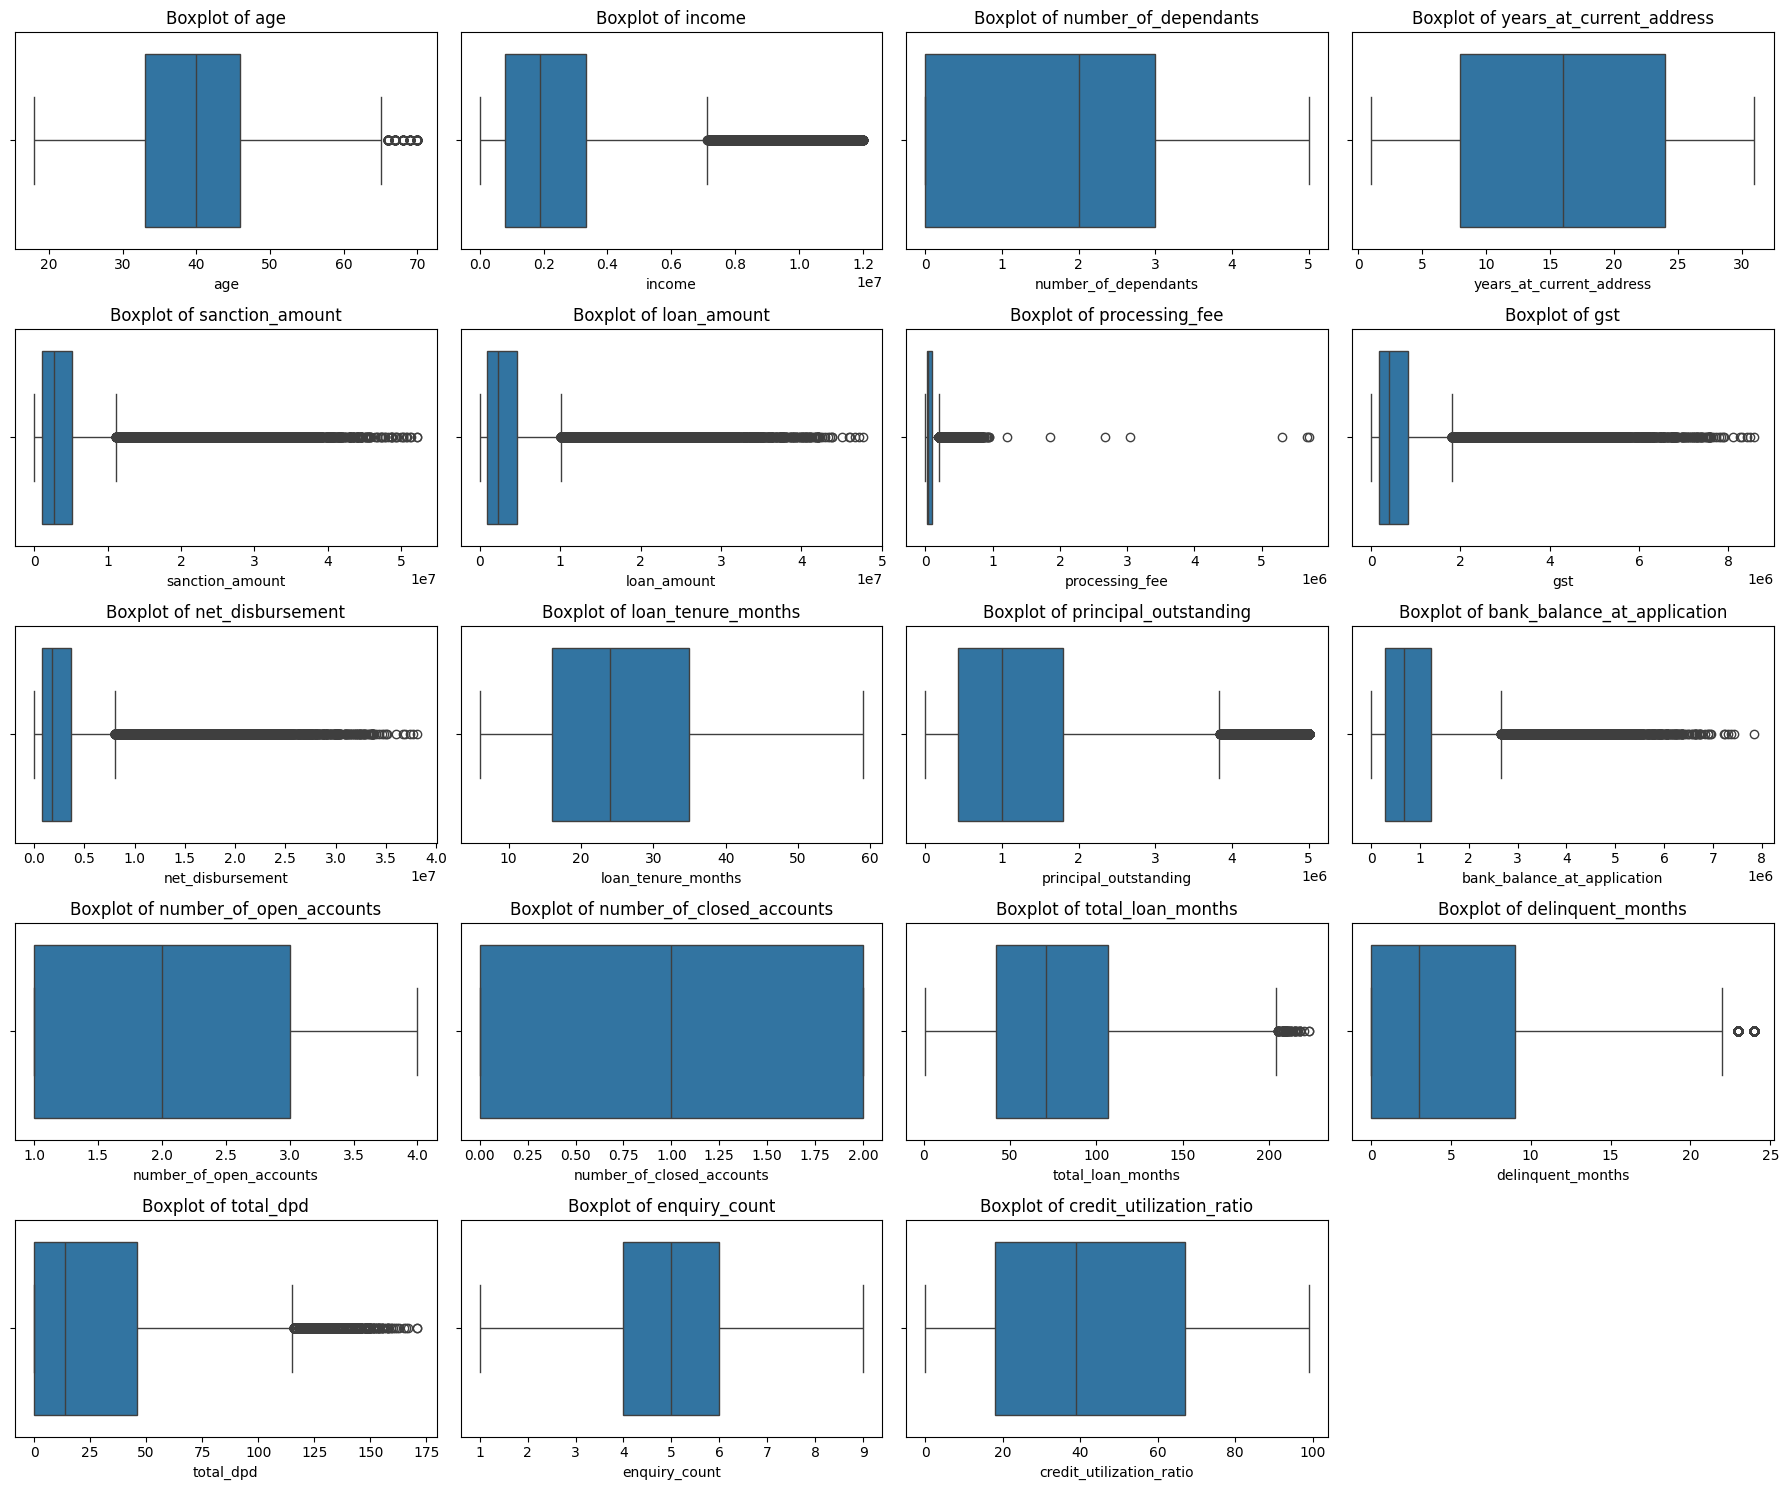

In [ ]:
import math

# Calculate number of rows needed for 4 columns
num_cols = 4
num_rows = math.ceil(len(columns_continuous) / num_cols)

# Create subplots with 4 charts per row
fig, axes = plt.subplots(num_rows, num_cols, figsize=(18, 3*num_rows))

# Flatten axes array for easier iteration
axes_flat = axes.flatten()

# Create boxplots
for idx, col in enumerate(columns_continuous):
    sns.boxplot(x=df_train[col], ax=axes_flat[idx])
    axes_flat[idx].set_title(f'Boxplot of {col}')

# Hide extra subplots if any
for idx in range(len(columns_continuous), len(axes_flat)):
    axes_flat[idx].axis('off')

plt.tight_layout()
plt.show()

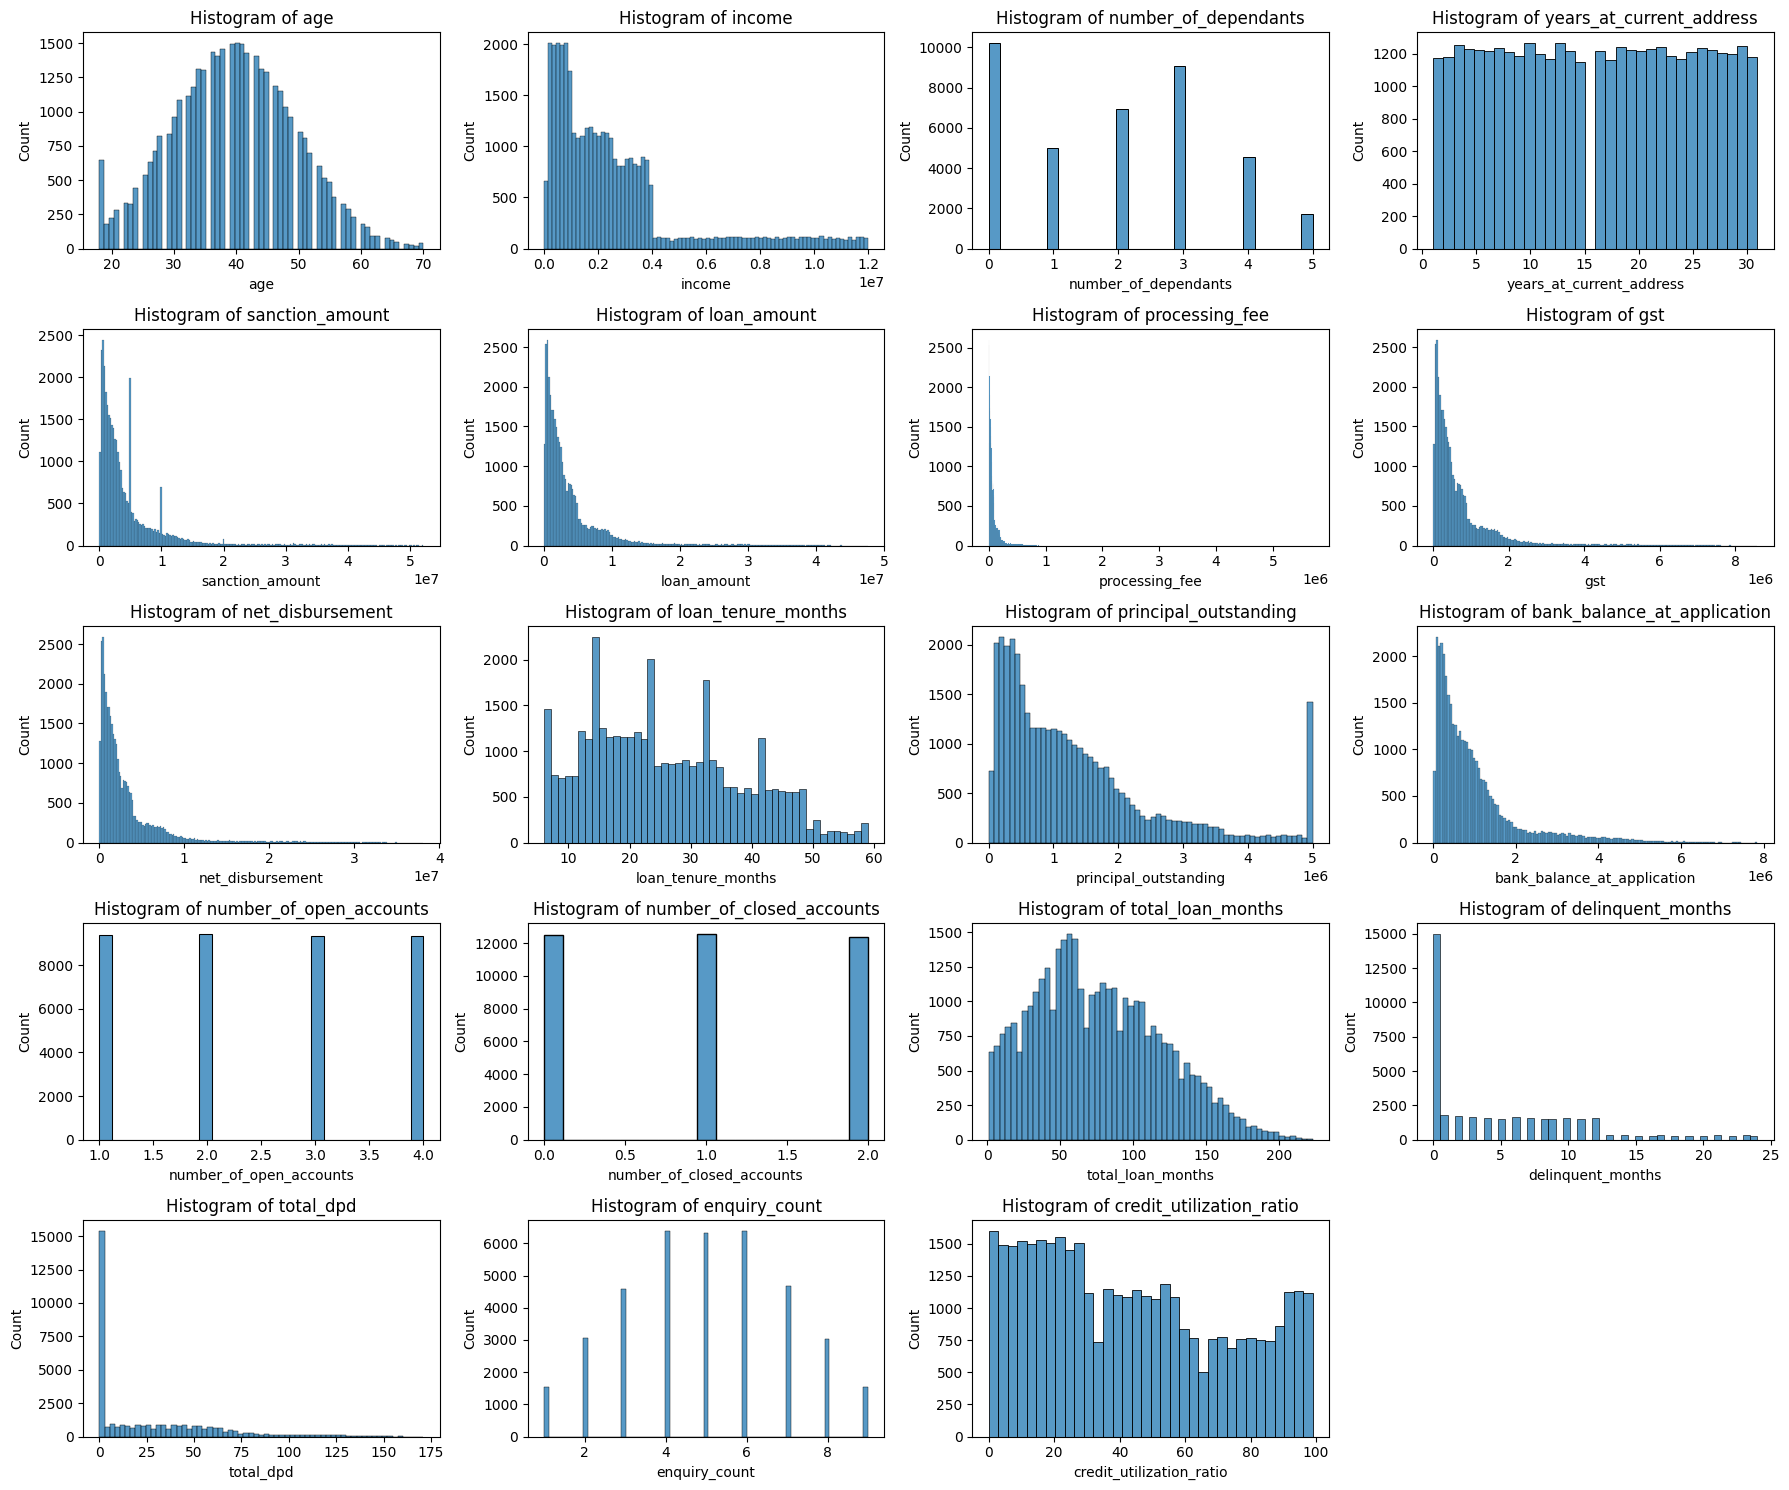

In [ ]:
import math

# Calculate number of rows needed for 4 columns
num_cols = 4
num_rows = math.ceil(len(columns_continuous) / num_cols)

# Create subplots with 4 charts per row
fig, axes = plt.subplots(num_rows, num_cols, figsize=(18, 3*num_rows))

# Flatten axes array for easier iteration
axes_flat = axes.flatten()

# Create histograms
for idx, col in enumerate(columns_continuous):
    sns.histplot(x=df_train[col], ax=axes_flat[idx])
    axes_flat[idx].set_title(f'Histogram of {col}')

# Hide extra subplots if any
for idx in range(len(columns_continuous), len(axes_flat)):
    axes_flat[idx].axis('off')

plt.tight_layout()
plt.show()

In [ ]:
df_train.processing_fee.describe()

count     37500.00
mean      80724.11
std      120830.65
min           0.00
25%       19180.00
50%       44700.00
75%       92000.00
max     5698029.90
Name: processing_fee, dtype: float64

In [ ]:
df_train[df_train['processing_fee'] > df_train['loan_amount']][["loan_amount", "processing_fee"]]

,loan_amount,processing_fee
23981,2234000,2669791.02
9898,3626000,5293543.52
47089,1738000,1858964.77
33705,3812000,5678020.86
12294,4639000,5698029.90
28174,966000,1214492.67
29305,2616000,3036378.01


In [ ]:
df_train.head()[["processing_fee"]]

,processing_fee
27434,65520.00
13400,50800.00
883,38400.00
7303,5960.00
45124,5200.00


In [ ]:
df_train[(df_train['processing_fee'] / df_train['loan_amount']) > 0.03][["loan_amount", "processing_fee"]]

,loan_amount,processing_fee
23981,2234000,2669791.02
9898,3626000,5293543.52
47089,1738000,1858964.77
33705,3812000,5678020.86
12294,4639000,5698029.90
28174,966000,1214492.67
29305,2616000,3036378.01


In [ ]:
df_train_1 = df_train[(df_train['processing_fee'] / df_train['loan_amount']) < 0.03].copy()

df_train_1[(df_train_1['processing_fee'] / df_train_1['loan_amount']) > 0.03][["loan_amount", "processing_fee"]]

,loan_amount,processing_fee


In [ ]:
# apply to same dataset for test data

df_test_1 = df_test[(df_test['processing_fee'] / df_test['loan_amount']) < 0.03].copy()

df_test_1[(df_test_1['processing_fee'] / df_test_1['loan_amount']) > 0.03][["loan_amount", "processing_fee"]]

,loan_amount,processing_fee


In [ ]:
columns_categorical

['gender',
 'marital_status',
 'employment_status',
 'residence_type',
 'city',
 'state',
 'zipcode',
 'loan_purpose',
 'loan_type',
 'default']

In [ ]:
for col in columns_categorical:
    print(f"Value counts for column '{col}':")
    print(col, " ---> ",df_train_1[col].unique())
    print("\n")

Value counts for column 'gender':
gender  --->  ['F' 'M']


Value counts for column 'marital_status':
marital_status  --->  ['Single' 'Married']


Value counts for column 'employment_status':
employment_status  --->  ['Salaried' 'Self-Employed']


Value counts for column 'residence_type':
residence_type  --->  ['Owned' 'Mortgage' 'Rented']


Value counts for column 'city':
city  --->  ['Ahmedabad' 'Delhi' 'Lucknow' 'Bangalore' 'Jaipur' 'Hyderabad' 'Kolkata'
 'Pune' 'Chennai' 'Mumbai']


Value counts for column 'state':
state  --->  ['Gujarat' 'Delhi' 'Uttar Pradesh' 'Karnataka' 'Rajasthan' 'Telangana'
 'West Bengal' 'Maharashtra' 'Tamil Nadu']


Value counts for column 'zipcode':
zipcode  --->  [380001 110001 226001 560001 302001 500001 700001 411001 600001 400001]


Value counts for column 'loan_purpose':
loan_purpose  --->  ['Home' 'Auto' 'Personal' 'Education' 'Personaal']


Value counts for column 'loan_type':
loan_type  --->  ['Secured' 'Unsecured']


Value counts for column 'defa

In [ ]:
df_train_1["loan_purpose"].replace('Personaal','Personal', inplace=True)
df_test_1["loan_purpose"].replace('Personaal','Personal', inplace=True)
df_train_1.loan_purpose.unique()


C:\Users\hapatil\AppData\Local\Temp\ipykernel_11352\1616106549.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_train_1["loan_purpose"].replace('Personaal','Personal', inplace=True)
C:\Users\hapatil\AppData\Local\Temp\ipykernel_11352\1616106549.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always

array(['Home', 'Auto', 'Personal', 'Education'], dtype=object)

<h3 align="center" style="color:red">Exploratory Data Analysis</h3>

In [ ]:
df_train_1[(df_train_1.gst/df_train_1.loan_amount) > 0.18][["loan_amount", "gst"]]

,loan_amount,gst


In [ ]:
df_train_1[(df_train_1.sanction_amount < df_train_1.loan_amount)][["loan_amount", "sanction_amount"]]

,loan_amount,sanction_amount


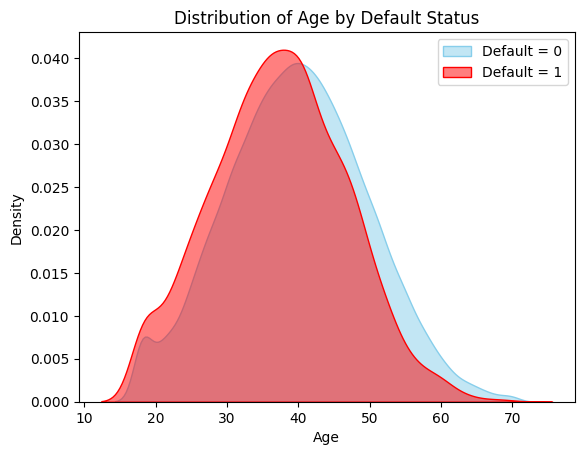

In [ ]:
sns.kdeplot(df_train_1[df_train_1.default == 0]["age"], fill=True, color="skyblue", alpha=0.5, label="Default = 0")
sns.kdeplot(df_train_1[df_train_1.default == 1]["age"], fill=True, color="red", alpha=0.5, label="Default = 1")
plt.title("Distribution of Age by Default Status")
plt.xlabel("Age")
plt.ylabel("Density")
plt.legend()
plt.show()

Insight:

1. Red graph is little bit shifted to the left of blue graph which indicates the people with young age are more likely default

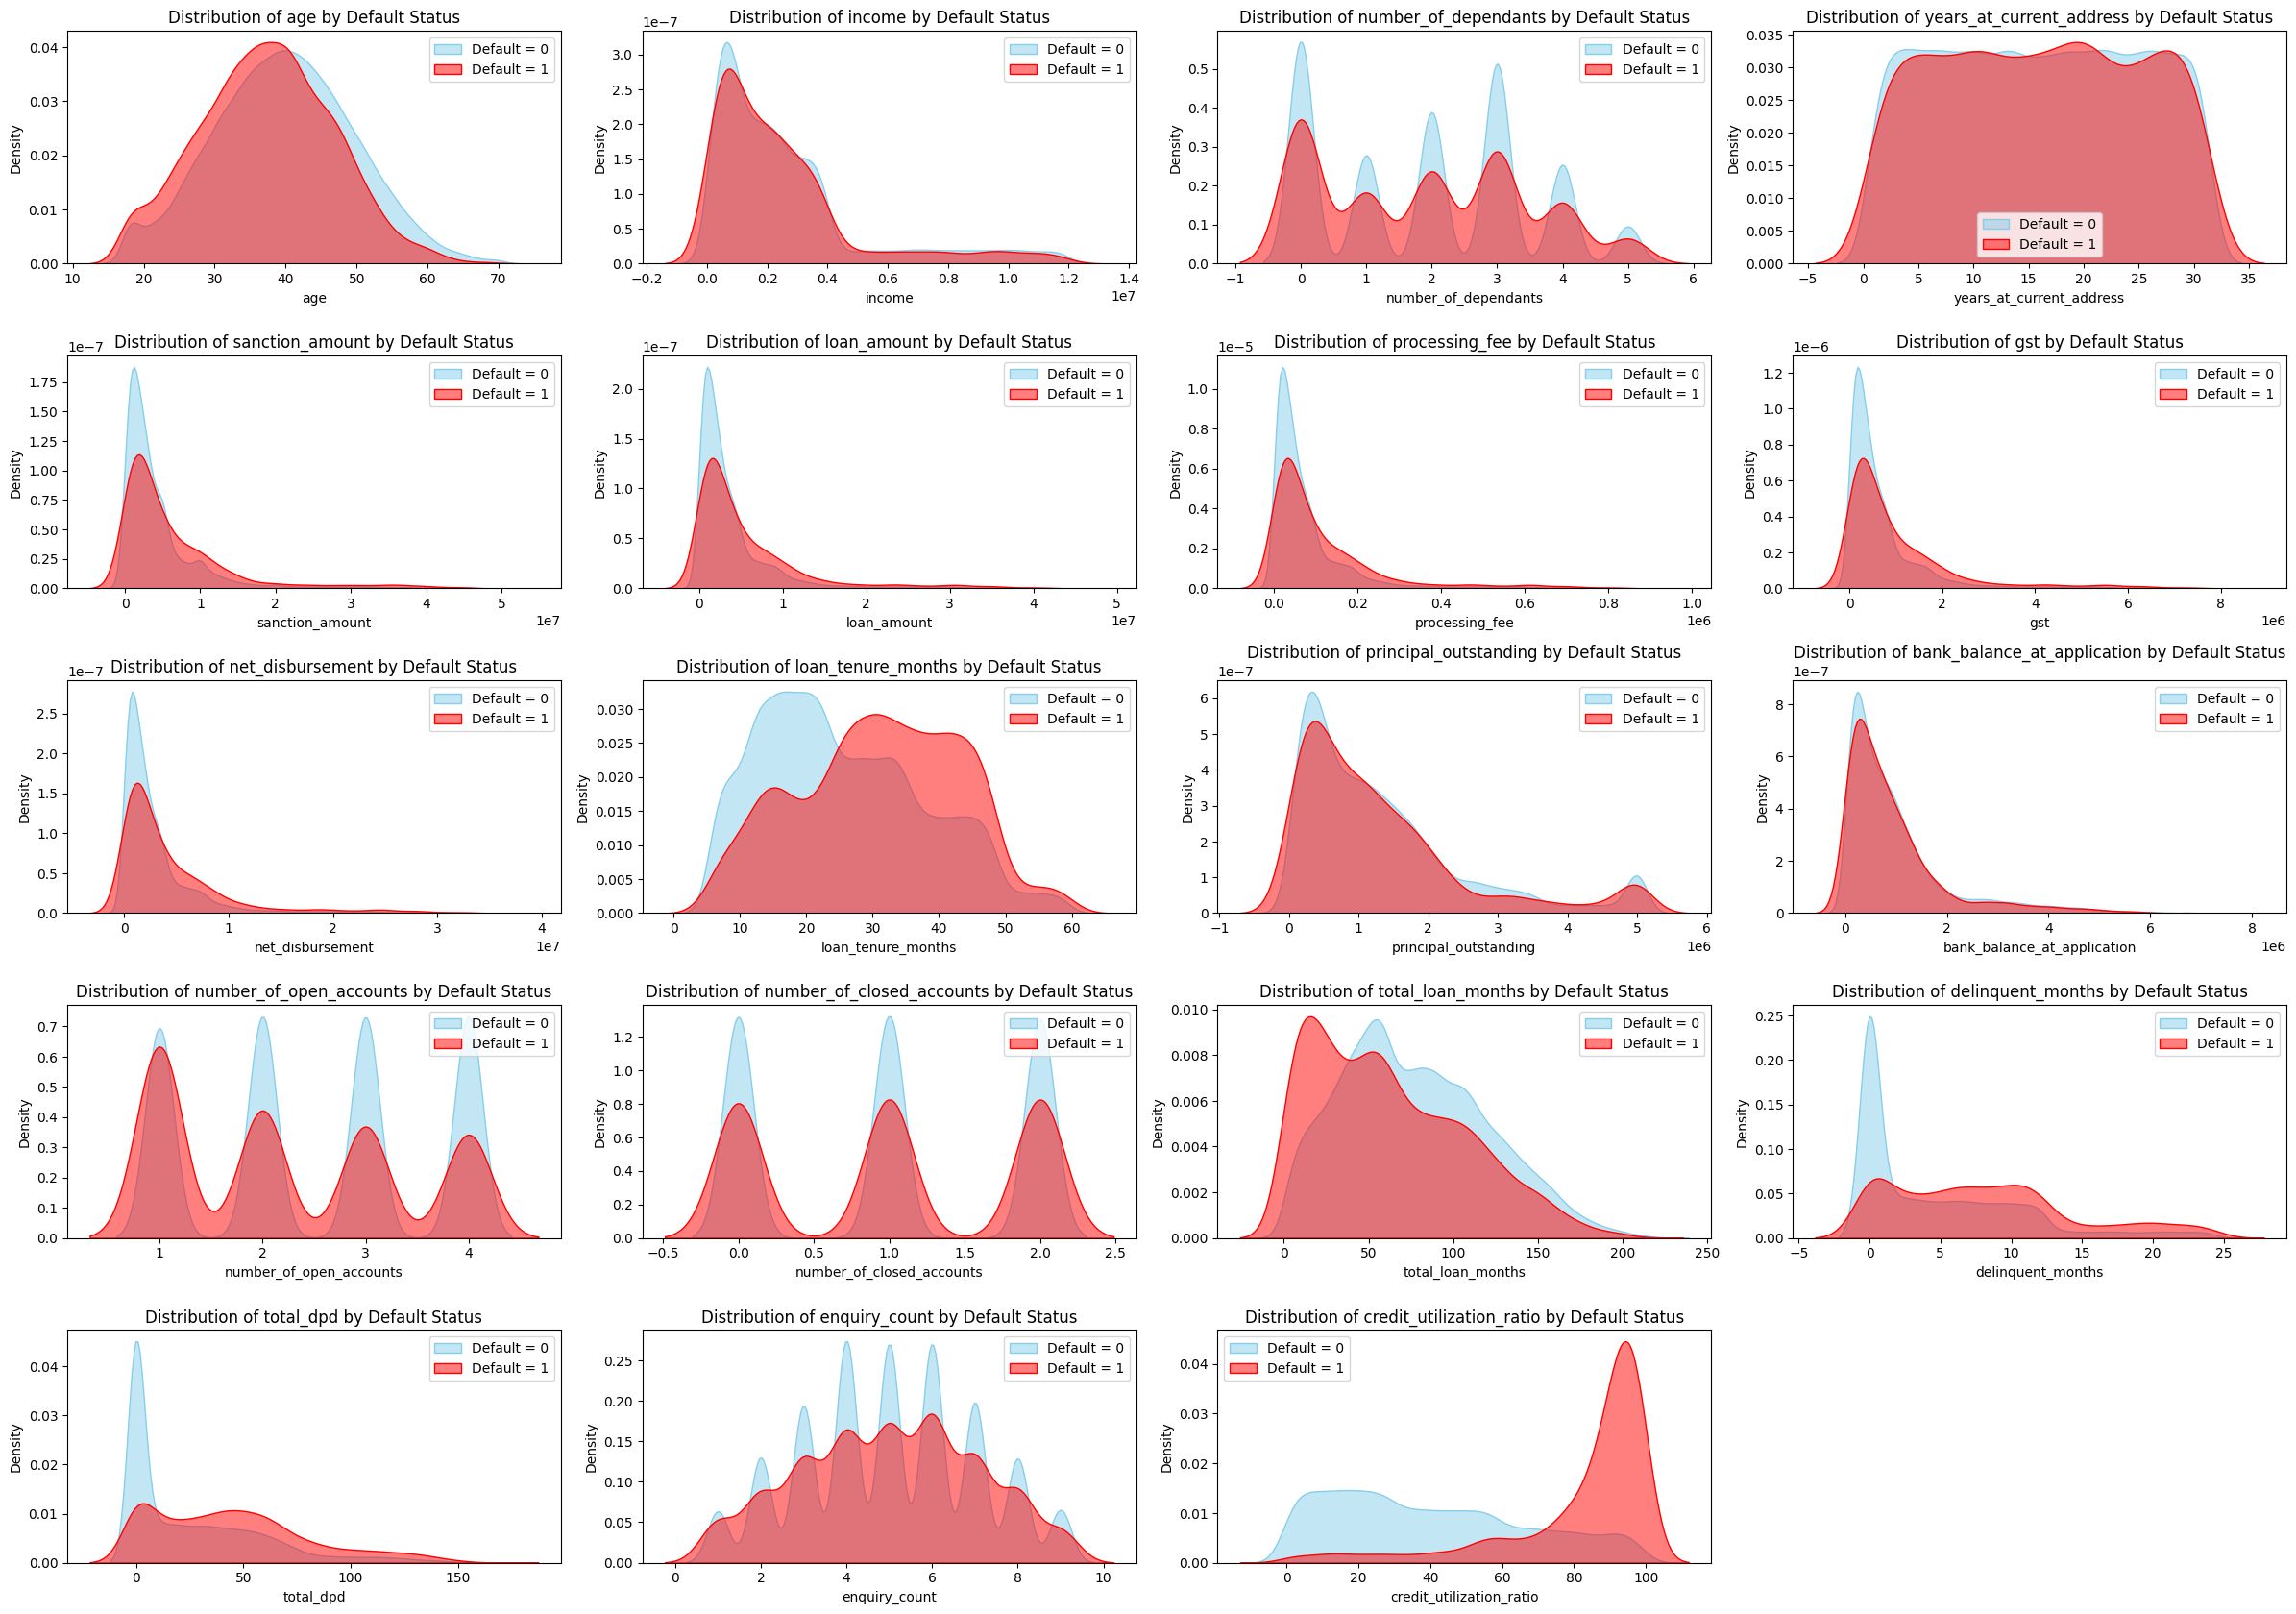

In [ ]:
plt.figure(figsize=(24, 20))

for idx, col in enumerate(columns_continuous):
    plt.subplot(6, 4, idx + 1)
    sns.kdeplot(df_train_1[df_train_1.default == 0][col], fill=True, color="skyblue", alpha=0.5, label="Default = 0")
    sns.kdeplot(df_train_1[df_train_1.default == 1][col], fill=True, color="red", alpha=0.5, label="Default = 1")
    plt.title(f"Distribution of {col} by Default Status")
    plt.xlabel(col)
    plt.ylabel("Density")
    plt.legend()
plt.tight_layout()
plt.show()

Insights:

1. In columns: loan_tenure_months, delinquent_months, total_dpd, credit_utilization, higher values indicate high likelyhood of becoming a default. Hence these 4 looks like strong predictors
1. In remaining columns the distributions do not give any obvious insights
1. Why loan_amount and income did not give any signs of being strong predictors? May be when we combine these two and get loan to income ratio (LTI), that may have influence on the target variable. We will explore more later

### Feature Engineering 

In [ ]:
df_train_1["loan_to_income"] = round(df_train_1['loan_amount'] / df_train_1['income'], 2)
df_test_1["loan_to_income"] = round(df_test_1['loan_amount'] / df_test_1['income'], 2)
df_train_1["loan_to_income"].describe()

count   37487.00
mean        1.55
std         0.97
min         0.30
25%         0.77
50%         1.16
75%         2.45
max         4.57
Name: loan_to_income, dtype: float64

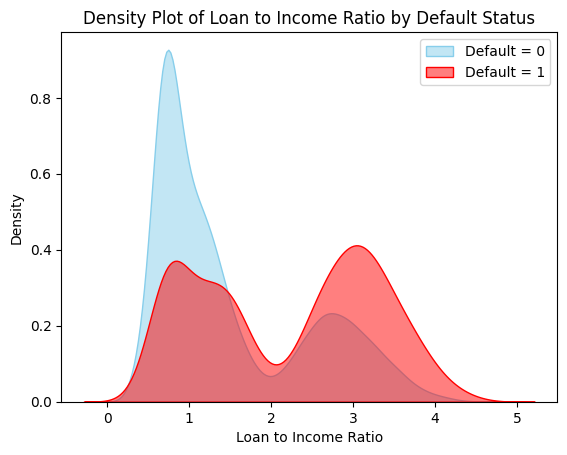

In [ ]:
sns.kdeplot(df_train_1[df_train_1.default == 0]["loan_to_income"], fill=True, color="skyblue", alpha=0.5, label="Default = 0")
sns.kdeplot(df_train_1[df_train_1.default == 1]["loan_to_income"], fill=True, color="red", alpha=0.5, label="Default = 1")
plt.xlabel("Loan to Income Ratio")
plt.ylabel("Density")
plt.title("Density Plot of Loan to Income Ratio by Default Status")
plt.legend()
plt.show()

In [ ]:
df_train_1[["delinquent_months", "total_loan_months"]]

,delinquent_months,total_loan_months
27434,6,90
13400,4,119
883,14,83
7303,0,37
45124,6,62
...,...,...
11284,23,129
44732,0,80
38158,0,8
860,5,130


In [ ]:
df_train_1["delinquency_ratio"] = round(df_train_1['delinquent_months']*100 / df_train_1['total_loan_months'], 1)
df_test_1["delinquency_ratio"] = round(df_test_1['delinquent_months']*100 / df_test_1['total_loan_months'], 1)
df_train_1[["delinquency_ratio", "delinquent_months", "total_loan_months"]].head()

,delinquency_ratio,delinquent_months,total_loan_months
27434,6.70,6,90
13400,3.40,4,119
883,16.90,14,83
7303,0.00,0,37
45124,9.70,6,62


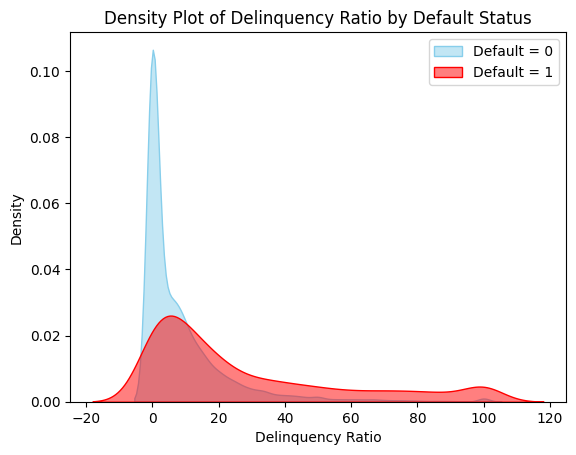

In [ ]:
sns.kdeplot(df_train_1[df_train_1.default == 0]["delinquency_ratio"], fill=True, color="skyblue", alpha=0.5, label="Default = 0")
sns.kdeplot(df_train_1[df_train_1.default == 1]["delinquency_ratio"], fill=True, color="red", alpha=0.5, label="Default = 1")
plt.xlabel("Delinquency Ratio")
plt.ylabel("Density")
plt.title("Density Plot of Delinquency Ratio by Default Status")
plt.legend()
plt.show()

In [ ]:
df_train_1["avg_dpd_per_delinquency"] = np.where(
    df_train_1['delinquent_months'] == 0,
    0,
    round(df_train_1['total_dpd'] / df_train_1['delinquent_months'], 1)
)
df_test_1["avg_dpd_per_delinquency"] = np.where(
    df_test_1['delinquent_months'] == 0,
    0,
    round(df_test_1['total_dpd'] / df_test_1['delinquent_months'], 1)
)

df_train_1["avg_dpd_per_delinquency"].isna().sum(), df_test_1["avg_dpd_per_delinquency"].isna().sum(), 

(np.int64(0), np.int64(0))

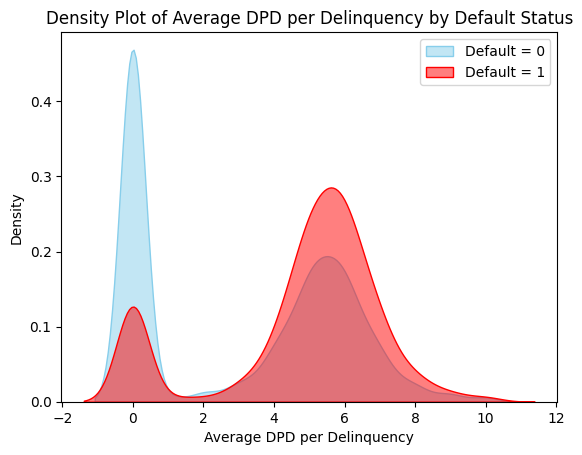

In [ ]:
sns.kdeplot(df_train_1[df_train_1.default == 0]["avg_dpd_per_delinquency"], fill=True, color="skyblue", alpha=0.5, label="Default = 0")
sns.kdeplot(df_train_1[df_train_1.default == 1]["avg_dpd_per_delinquency"], fill=True, color="red", alpha=0.5, label="Default = 1")
plt.xlabel("Average DPD per Delinquency")
plt.ylabel("Density")
plt.title("Density Plot of Average DPD per Delinquency by Default Status")
plt.legend()
plt.show()

### Feature selection

In [ ]:
df_train_1.columns

Index(['cust_id', 'age', 'gender', 'marital_status', 'employment_status',
       'income', 'number_of_dependants', 'residence_type',
       'years_at_current_address', 'city', 'state', 'zipcode', 'loan_id',
       'loan_purpose', 'loan_type', 'sanction_amount', 'loan_amount',
       'processing_fee', 'gst', 'net_disbursement', 'loan_tenure_months',
       'principal_outstanding', 'bank_balance_at_application',
       'disbursal_date', 'installment_start_dt', 'number_of_open_accounts',
       'number_of_closed_accounts', 'total_loan_months', 'delinquent_months',
       'total_dpd', 'enquiry_count', 'credit_utilization_ratio', 'default',
       'loan_to_income', 'delinquency_ratio', 'avg_dpd_per_delinquency'],
      dtype='object')

In [ ]:
df_train_2 = df_train_1.drop(columns=['cust_id', 'loan_id'])
df_test_2 = df_test_1.drop(columns=['cust_id', 'loan_id'])

In [ ]:
df_train_3 = df_train_2.drop(["disbursal_date", "installment_start_dt", "loan_amount", "income", 
                             "total_loan_months", "delinquent_months", "total_dpd"], axis=1)

df_test_3 = df_test_2.drop(["disbursal_date", "installment_start_dt", "loan_amount", "income", 
                             "total_loan_months", "delinquent_months", "total_dpd"], axis=1)

In [ ]:
df_train_3.columns

Index(['age', 'gender', 'marital_status', 'employment_status',
       'number_of_dependants', 'residence_type', 'years_at_current_address',
       'city', 'state', 'zipcode', 'loan_purpose', 'loan_type',
       'sanction_amount', 'processing_fee', 'gst', 'net_disbursement',
       'loan_tenure_months', 'principal_outstanding',
       'bank_balance_at_application', 'number_of_open_accounts',
       'number_of_closed_accounts', 'enquiry_count',
       'credit_utilization_ratio', 'default', 'loan_to_income',
       'delinquency_ratio', 'avg_dpd_per_delinquency'],
      dtype='object')

In [ ]:
df_train_3.select_dtypes(include=['int64', 'float64']).columns

Index(['age', 'number_of_dependants', 'years_at_current_address', 'zipcode',
       'sanction_amount', 'processing_fee', 'gst', 'net_disbursement',
       'loan_tenure_months', 'principal_outstanding',
       'bank_balance_at_application', 'number_of_open_accounts',
       'number_of_closed_accounts', 'enquiry_count',
       'credit_utilization_ratio', 'default', 'loan_to_income',
       'delinquency_ratio', 'avg_dpd_per_delinquency'],
      dtype='object')

Calculate variance inflation factor to multi co-linearity factor

In [ ]:
X_train = df_train_3.drop(columns=['default'], axis="columns")
y_train = df_train_3['default']

from sklearn.preprocessing import StandardScaler, MinMaxScaler, RobustScaler

cols_to_scale = X_train.select_dtypes(include=['int64', 'float64']).columns

scaler = MinMaxScaler()
X_train[cols_to_scale] = scaler.fit_transform(X_train[cols_to_scale])

X_train.head()

,age,gender,marital_status,employment_status,number_of_dependants,residence_type,years_at_current_address,city,state,zipcode,...,loan_tenure_months,principal_outstanding,bank_balance_at_application,number_of_open_accounts,number_of_closed_accounts,enquiry_count,credit_utilization_ratio,loan_to_income,delinquency_ratio,avg_dpd_per_delinquency
27434,0.52,F,Single,Salaried,0.00,Owned,0.13,Ahmedabad,Gujarat,0.46,...,0.34,0.18,0.07,1.00,1.00,0.88,0.60,0.61,0.07,0.55
13400,0.21,M,Single,Salaried,0.00,Owned,0.80,Delhi,Delhi,0.00,...,0.51,0.20,0.12,0.67,0.50,0.38,0.93,0.18,0.03,0.42
883,0.62,F,Single,Self-Employed,0.00,Mortgage,0.93,Lucknow,Uttar Pradesh,0.20,...,0.25,0.27,0.10,0.33,0.50,0.38,0.84,0.08,0.17,0.56
7303,0.48,F,Single,Self-Employed,0.20,Owned,0.87,Bangalore,Karnataka,0.76,...,0.28,0.03,0.01,0.00,0.50,0.50,0.34,0.19,0.00,0.00
45124,0.25,F,Single,Salaried,0.00,Owned,0.87,Jaipur,Rajasthan,0.33,...,0.74,0.01,0.01,0.33,0.00,0.50,0.19,0.36,0.10,0.47


In [ ]:
X_train.describe()

,age,number_of_dependants,years_at_current_address,zipcode,sanction_amount,processing_fee,gst,net_disbursement,loan_tenure_months,principal_outstanding,bank_balance_at_application,number_of_open_accounts,number_of_closed_accounts,enquiry_count,credit_utilization_ratio,loan_to_income,delinquency_ratio,avg_dpd_per_delinquency
count,37487.00,37487.00,37487.00,37487.00,37487.00,37487.00,37487.00,37487.00,37487.00,37487.00,37487.00,37487.00,37487.00,37487.00,37487.00,37487.00,37487.00,37487.00
mean,0.41,0.39,0.50,0.52,0.09,0.08,0.08,0.08,0.38,0.26,0.12,0.50,0.50,0.50,0.44,0.29,0.10,0.33
std,0.19,0.31,0.30,0.29,0.12,0.11,0.11,0.11,0.23,0.24,0.13,0.37,0.41,0.25,0.30,0.23,0.17,0.29
min,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
25%,0.29,0.00,0.23,0.33,0.02,0.02,0.02,0.02,0.19,0.08,0.03,0.00,0.00,0.38,0.18,0.11,0.00,0.00
50%,0.42,0.40,0.50,0.49,0.05,0.05,0.05,0.05,0.34,0.19,0.08,0.33,0.50,0.50,0.39,0.20,0.04,0.43
75%,0.54,0.60,0.77,0.76,0.10,0.10,0.10,0.10,0.55,0.35,0.16,0.67,1.00,0.62,0.68,0.50,0.13,0.58
max,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00


In [ ]:
X_test = df_test_3.drop(columns=['default'], axis="columns")
y_test = df_test_3['default']

X_test[cols_to_scale] = scaler.transform(X_test[cols_to_scale])

X_test.describe()

,age,number_of_dependants,years_at_current_address,zipcode,sanction_amount,processing_fee,gst,net_disbursement,loan_tenure_months,principal_outstanding,bank_balance_at_application,number_of_open_accounts,number_of_closed_accounts,enquiry_count,credit_utilization_ratio,loan_to_income,delinquency_ratio,avg_dpd_per_delinquency
count,12498.00,12498.00,12498.00,12498.00,12498.00,12498.00,12498.00,12498.00,12498.00,12498.00,12498.00,12498.00,12498.00,12498.00,12498.00,12498.00,12498.00,12498.00
mean,0.41,0.39,0.50,0.53,0.09,0.08,0.08,0.08,0.38,0.26,0.12,0.50,0.51,0.50,0.44,0.29,0.10,0.33
std,0.19,0.31,0.30,0.29,0.12,0.11,0.11,0.11,0.24,0.25,0.13,0.37,0.41,0.26,0.30,0.23,0.17,0.29
min,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,-0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
25%,0.29,0.00,0.23,0.33,0.02,0.02,0.02,0.02,0.19,0.08,0.03,0.00,0.00,0.38,0.18,0.11,0.00,0.00
50%,0.42,0.40,0.50,0.51,0.05,0.05,0.05,0.05,0.36,0.20,0.08,0.67,0.50,0.50,0.39,0.20,0.04,0.43
75%,0.54,0.60,0.77,0.76,0.10,0.10,0.10,0.10,0.55,0.35,0.16,1.00,1.00,0.75,0.68,0.50,0.13,0.58
max,1.00,1.00,1.00,1.00,0.95,1.00,1.00,1.00,1.00,1.00,0.88,1.00,1.00,1.00,1.00,1.00,1.00,1.00


In [ ]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

def calculate_vif(data):
    vif_data = pd.DataFrame()
    vif_data["feature"] = data.columns
    vif_data["VIF"] = [variance_inflation_factor(data.values, i) for i in range(data.shape[1])]
    return vif_data

In [ ]:
calculate_vif(X_train[cols_to_scale])

c:\Office_Data\Prsonal data\Prsonal data\Resume\myrepo\GenAIAndMachineLearningProjects\PracticeCode\.venv\Lib\site-packages\statsmodels\stats\outliers_influence.py:197: RuntimeWarning: divide by zero encountered in scalar divide
  vif = 1. / (1. - r_squared_i)


,feature,VIF
0,age,5.72
1,number_of_dependants,2.73
2,years_at_current_address,3.42
3,zipcode,3.79
4,sanction_amount,102.15
5,processing_fee,inf
6,gst,inf
7,net_disbursement,inf
8,loan_tenure_months,6.14
9,principal_outstanding,16.28
